# 07 — Sensitivity analysis

**Deliverable D15.**

Every headline number rests on choices forced by the data rather than chosen on merit.
This sweeps them so each result ships with a **range** rather than a point estimate.

| axis | why it is in doubt |
|---|---|
| `reactive_orientation` | unresolved — 213 sites fit as-delivered, 106 flipped |
| capacity basis | no nameplate; the whole curve is scaled by an *observed* quantile |
| `voltage_aggregation` | `mean` (correct for three-phase) vs `max` (legacy Method A) |
| `tolerance_fraction` | ±4% re-anchored to `s_99` because there is no nameplate |
| night-anomaly sites | 5 likely storage + 15 stray timestamps, in or out |
| peak-hour window | the legacy query used an inclusive `BETWEEN` |

**How to read a sweep.** A number that barely moves is robust to that choice. A number
that moves a lot is *conditional* on it and must be reported as such — never averaged
across the sweep, which would invent a value no defensible configuration produces.

This is the slow notebook: each row is a full interval-level rescore.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next((p for p in (_current, *_current.parents)
                  if (p / "oem_analysis").is_dir() and (p / "bms_sa_review").is_dir()), None)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from oem_analysis.config import se_config as C
from oem_analysis.lib import se_store, se_contract as contract, se_params
pd.set_option("display.max_columns", None); pd.set_option("display.width", 220)
con = se_store.connect()
config, params = se_params.CONFIG, se_params.PARAMS
from oem_analysis.lib import se_sensitivity as sens
from oem_analysis.lib import se_conformance as cf
from oem_analysis.lib import se_plots as plots
from oem_analysis.lib import se_adverse as adv

adverse = adv.classify_adverse_sites(con, config)
display(pd.DataFrame([{"axis": k, "changes": str(v) or "(defaults)"}
                      for k, v in sens.DEFAULT_SWEEPS.items()]))

,axis,changes
0,baseline,{}
1,reactive sign: flipped,{'reactive_orientation': 'flipped'}
2,voltage: max of phases,{'voltage_aggregation': 'max'}
3,capacity basis: s_95,"{'rating_basis': 's_95', 'empirical_limit_basi..."
4,capacity basis: s_max,"{'rating_basis': 's_max', 'empirical_limit_bas..."
5,tolerance: 2%,{'tolerance_fraction': 0.02}
6,tolerance: 6%,{'tolerance_fraction': 0.06}
7,include night-anomaly sites,{'night_anomaly_selection': 'include'}
8,exclude derating intervals,{'derating_selection': 'exclude'}
9,sites with >= 300 days,{'min_days_observed': 300}


## Volt-VAr conformance sweep

Watch `assessable_intervals` alongside the rate. A sweep that moves the rate by moving
the **denominator** is telling you something quite different from one that moves the
numerator.

In [2]:
conf_sweep = sens.sweep_conformance(con, config=config, params=params)
display(conf_sweep)

  baseline                           reduced NC  60.40%  sites conformant  18.61%
  reactive sign: flipped             reduced NC  65.49%  sites conformant   9.49%
  voltage: max of phases             reduced NC  64.91%  sites conformant  13.29%
  capacity basis: s_95               reduced NC  59.82%  sites conformant  18.80%
  capacity basis: s_max              reduced NC  61.10%  sites conformant  18.23%
  tolerance: 2%                      reduced NC  64.48%  sites conformant  16.58%
  tolerance: 6%                      reduced NC  55.92%  sites conformant  20.51%
  include night-anomaly sites        reduced NC  60.31%  sites conformant  18.69%
  exclude derating intervals         reduced NC  57.73%  sites conformant  18.99%
  sites with >= 300 days             reduced NC  60.20%  sites conformant  18.99%
  single-phase only                  reduced NC  65.75%  sites conformant  13.13%
  three-phase only                   reduced NC  45.10%  sites conformant  33.98%


,scenario,changes,n_sites,assessable_intervals,reduced_nonconf_pct,Q_adverse_pct,Q_significant_shortfall_pct,pct_sites_conformant
0,baseline,(defaults),1580,50697287,60.40,45.488,12.009,18.61
1,reactive sign: flipped,reactive_orientation=flipped,1580,50697287,65.49,24.335,38.255,9.49
2,voltage: max of phases,voltage_aggregation=max,1580,50697287,64.91,45.514,16.038,13.29
3,capacity basis: s_95,"rating_basis=s_95, empirical_limit_basis=s_95,...",1580,51740937,59.82,45.913,11.790,18.80
4,capacity basis: s_max,"rating_basis=s_max, empirical_limit_basis=s_ma...",1580,49468362,61.10,44.930,12.193,18.23
5,tolerance: 2%,tolerance_fraction=0.02,1580,50697287,64.48,47.236,13.257,16.58
6,tolerance: 6%,tolerance_fraction=0.06,1580,50697287,55.92,43.200,10.653,20.51
7,include night-anomaly sites,night_anomaly_selection=include,1600,51352135,60.31,45.552,11.856,18.69
8,exclude derating intervals,derating_selection=exclude,1580,41755279,57.73,42.075,13.483,18.99
9,sites with >= 300 days,min_days_observed=300,1501,49276980,60.20,45.248,12.045,18.99


In [3]:
display(sens.tornado(conf_sweep, "reduced_nonconf_pct"))
display(sens.tornado(conf_sweep, "pct_sites_conformant"))

,scenario,changes,reduced_nonconf_pct,baseline,delta,pct_change
0,three-phase only,phase_cohort=three,45.10,60.4,-15.30,-25.33
1,single-phase only,phase_cohort=single,65.75,60.4,5.35,8.86
2,reactive sign: flipped,reactive_orientation=flipped,65.49,60.4,5.09,8.43
3,voltage: max of phases,voltage_aggregation=max,64.91,60.4,4.51,7.47
4,tolerance: 6%,tolerance_fraction=0.06,55.92,60.4,-4.48,-7.42
5,tolerance: 2%,tolerance_fraction=0.02,64.48,60.4,4.08,6.75
6,exclude derating intervals,derating_selection=exclude,57.73,60.4,-2.67,-4.42
7,capacity basis: s_max,"rating_basis=s_max, empirical_limit_basis=s_ma...",61.10,60.4,0.70,1.16
8,capacity basis: s_95,"rating_basis=s_95, empirical_limit_basis=s_95,...",59.82,60.4,-0.58,-0.96
9,sites with >= 300 days,min_days_observed=300,60.20,60.4,-0.20,-0.33


,scenario,changes,pct_sites_conformant,baseline,delta,pct_change
0,three-phase only,phase_cohort=three,33.98,18.61,15.37,82.59
1,reactive sign: flipped,reactive_orientation=flipped,9.49,18.61,-9.12,-49.01
2,single-phase only,phase_cohort=single,13.13,18.61,-5.48,-29.45
3,voltage: max of phases,voltage_aggregation=max,13.29,18.61,-5.32,-28.59
4,tolerance: 2%,tolerance_fraction=0.02,16.58,18.61,-2.03,-10.91
5,tolerance: 6%,tolerance_fraction=0.06,20.51,18.61,1.90,10.21
6,sites with >= 300 days,min_days_observed=300,18.99,18.61,0.38,2.04
7,exclude derating intervals,derating_selection=exclude,18.99,18.61,0.38,2.04
8,capacity basis: s_max,"rating_basis=s_max, empirical_limit_basis=s_ma...",18.23,18.61,-0.38,-2.04
9,capacity basis: s_95,"rating_basis=s_95, empirical_limit_basis=s_95,...",18.80,18.61,0.19,1.02


## Method A sweep

Watch `energy_kWh` against `symptom_intervals`. The capacity basis moves both, in
**opposite directions**: a lower `s_limit` makes the apparent-limit test fire more often
(raising the count) while shrinking the headroom displacement per interval (lowering the
energy per event). Reporting only one of them would mislead.

In [4]:
a_sweep = sens.sweep_method_a(con, config=config, params=params, adverse=adverse)
display(a_sweep)

  [cohort] baseline                                7,040 kWh
  [cohort] reactive sign: flipped                  5,095 kWh
  [cohort] voltage: max of phases                  6,852 kWh
  [cohort] capacity basis: s_95                   11,794 kWh
  [cohort] capacity basis: s_max                   4,616 kWh
  [cohort] tolerance: 2%                           5,741 kWh
  [cohort] tolerance: 6%                           8,373 kWh
  [cohort] exclude derating intervals              2,066 kWh
  [cohort] sites with >= 300 days                  6,631 kWh
  [cohort] single-phase only                       4,557 kWh
  [cohort] three-phase only                        2,483 kWh
  [params] peak window 11-14 (default)             7,040 kWh
  [params] peak window 11-15 (legacy inclusive)      7,747 kWh
  [params] peak window 10-16 (wide)                9,584 kWh
  [params] no symptom gate                         7,040 kWh


,scenario,changes,eligible_sites,symptom_sites,eligible_intervals,symptom_intervals,symptom_pct_of_eligible,energy_kWh
0,baseline,(defaults),1471,600,15554919,944069,6.0693,7039.9
1,reactive sign: flipped,reactive_orientation=flipped,1471,978,15554919,1755997,11.2890,5095.4
2,voltage: max of phases,voltage_aggregation=max,1472,601,15967251,957240,5.9950,6851.8
3,capacity basis: s_95,"rating_basis=s_95, empirical_limit_basis=s_95,...",1471,601,15554919,1523745,9.7959,11794.2
4,capacity basis: s_max,"rating_basis=s_max, empirical_limit_basis=s_ma...",1471,581,15554919,478087,3.0735,4615.9
5,tolerance: 2%,tolerance_fraction=0.02,1471,598,15554919,778475,5.0047,5741.2
6,tolerance: 6%,tolerance_fraction=0.06,1471,601,15554919,1121427,7.2095,8372.9
7,exclude derating intervals,derating_selection=exclude,1471,594,11467880,317853,2.7717,2066.2
8,sites with >= 300 days,min_days_observed=300,1396,573,15100667,913876,6.0519,6631.0
9,single-phase only,phase_cohort=single,1058,190,11312789,338769,2.9946,4556.7


In [5]:
display(sens.tornado(a_sweep, "energy_kWh"))

conf_sweep.to_csv(C.ARTEFACT_DIR / "sensitivity_conformance.csv", index=False)
a_sweep.to_csv(C.ARTEFACT_DIR / "sensitivity_method_a.csv", index=False)
print(f"-> {C.ARTEFACT_DIR / 'sensitivity_conformance.csv'}")
print(f"-> {C.ARTEFACT_DIR / 'sensitivity_method_a.csv'}")

,scenario,changes,energy_kWh,baseline,delta,pct_change
0,exclude derating intervals,derating_selection=exclude,2066.2,7039.9,-4973.7,-70.65
1,capacity basis: s_95,"rating_basis=s_95, empirical_limit_basis=s_95,...",11794.2,7039.9,4754.3,67.53
2,three-phase only,phase_cohort=three,2483.2,7039.9,-4556.7,-64.73
3,peak window 10-16 (wide),"peak_hour_start=10, peak_hour_end=16",9583.6,7039.9,2543.7,36.13
4,single-phase only,phase_cohort=single,4556.7,7039.9,-2483.2,-35.27
5,capacity basis: s_max,"rating_basis=s_max, empirical_limit_basis=s_ma...",4615.9,7039.9,-2424.0,-34.43
6,reactive sign: flipped,reactive_orientation=flipped,5095.4,7039.9,-1944.5,-27.62
7,tolerance: 6%,tolerance_fraction=0.06,8372.9,7039.9,1333.0,18.93
8,tolerance: 2%,tolerance_fraction=0.02,5741.2,7039.9,-1298.7,-18.45
9,peak window 11-15 (legacy inclusive),peak_hour_end=15,7747.1,7039.9,707.2,10.05


-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\oem_analysis\artefacts\sensitivity_conformance.csv
-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\oem_analysis\artefacts\sensitivity_method_a.csv


## Minimum-interval sensitivity

A site with **one** exposed interval can only score 0% or 100%. The 10% rule has no
meaning there — the verdict is decided by a single reading — yet such a site currently
carries the same weight in the fleet rate as one observed for a thousand intervals.

**What the reference implementations do**, checked directly:

- **Hossein's original** applies *no* minimum, for either response. The only count filter
  in `SolA2024_Analysis` is `total_count > 5` in `sustained_operation.ipynb` — a different
  analysis. There is no site-level Volt-Watt rate in that repo at all.
- **`bms_sa_review`** sets `min_site_intervals = 1` (i.e. none, matching the original) but
  provides `minimum_interval_sensitivity` and **plots it for both Volt-Watt variants** in
  `02_conformance_curtailment_analysis.ipynb`.

So the defensible position is not a chosen threshold — it is this curve, reported. The
sweep below keeps `min = 1` as the baseline and runs to 20.

In [6]:
vvar_site_day = cf.voltvar_site_day(con, config, params)
vwatt_site_day = cf.voltwatt_site_day(con, config)

print("How thin is the evidence? — Volt-Watt")
display(sens.min_interval_exposure_profile(vwatt_site_day, "voltwatt", config))

How thin is the evidence? — Volt-Watt
573 sites with >= 1 exposed interval | median 43 | 109 non-conformant


,intervals_at_or_below,n_sites,pct_of_tested_sites,n_nonconformant,pct_of_all_nonconformant
0,1,85,14.834,5,4.587
1,2,114,19.895,8,7.339
2,3,135,23.560,10,9.174
3,5,168,29.319,16,14.679
4,10,219,38.220,25,22.936
5,20,246,42.932,29,26.606
6,50,292,50.960,35,32.110
7,100,324,56.545,37,33.945


### Volt-Watt

`pct_dropped_conformant` is the column that settles the interpretation. It is the share of
the **discarded** sites that were conformant:

- near **50%** → the filter is neutral, and any movement in the headline is real;
- well **above 50%** → the filter is removing well-behaved sparse sites, so raising the
  minimum drives the rate **down**, and the fall is an artefact of the rule rather than
  worse inverters.

,min_intervals,n_sites,n_dropped,pct_sites_dropped,pct_conformant,pct_nonconformant,pct_dropped_conformant,median_nonconf_frac
0,1,573,0,0.000,80.977,19.023,NaN,0.0000
1,2,488,85,14.834,78.689,21.311,94.118,0.0000
2,3,459,114,19.895,77.996,22.004,92.982,0.0000
3,4,438,135,23.560,77.397,22.603,92.593,0.0010
4,5,424,149,26.003,76.887,23.113,92.617,0.0016
5,6,405,168,29.319,77.037,22.963,90.476,0.0021
6,7,387,186,32.461,77.261,22.739,88.710,0.0030
7,8,369,204,35.602,76.965,23.035,88.235,0.0050
8,9,363,210,36.649,76.860,23.140,88.095,0.0053
9,10,360,213,37.173,76.667,23.333,88.263,0.0054


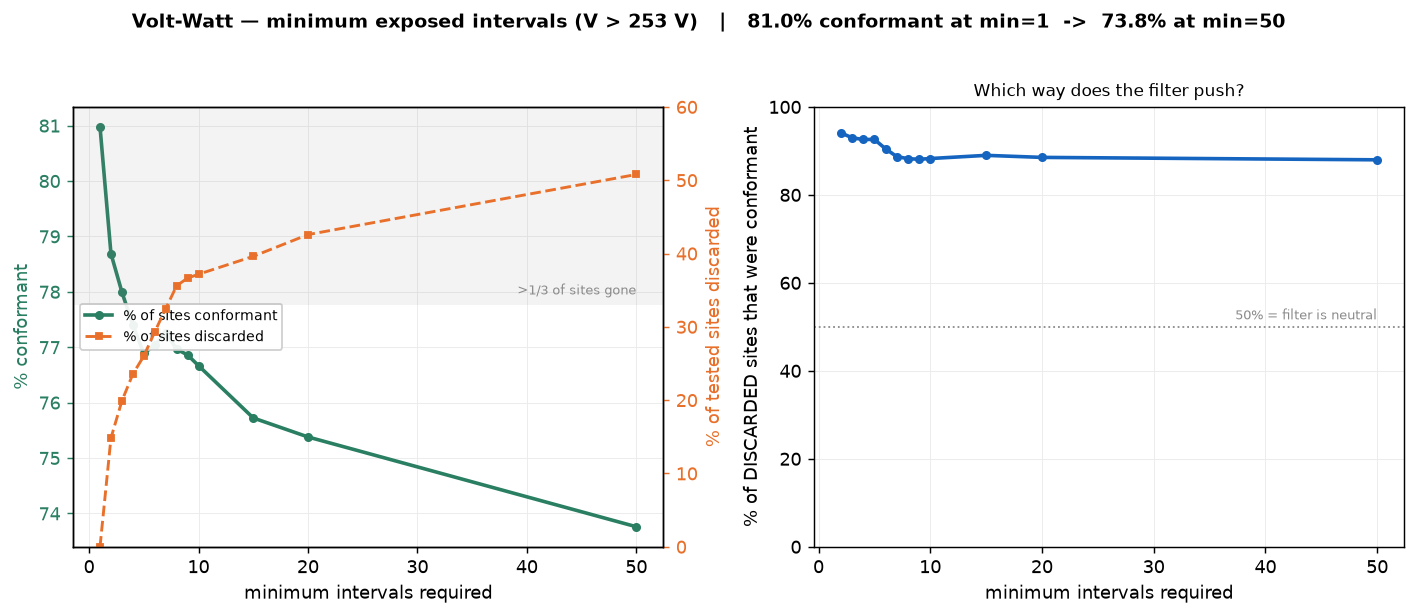

In [7]:
vw_min_sweep = sens.sweep_min_intervals(vwatt_site_day, "voltwatt", config)
display(vw_min_sweep.drop(columns="denominator"))
display(plots.plot_min_interval_sweep(
    vw_min_sweep, "Volt-Watt — minimum exposed intervals (V > 253 V)"))

### Volt-VAr

Same sweep against the capability-assessable denominator. Expect it to be far flatter:
every site in this fleet has assessable Volt-VAr intervals and the median count is orders
of magnitude larger, so the rule has almost nothing to bite on. That contrast is the point
— it shows the sensitivity is a property of **Volt-Watt exposure**, not of the 10% rule.

,min_intervals,n_sites,n_dropped,pct_sites_dropped,pct_conformant,pct_nonconformant,pct_dropped_conformant,median_nonconf_frac
0,1,1580,0,0.0,18.608,81.392,NaN,0.7458
1,2,1580,0,0.0,18.608,81.392,NaN,0.7458
2,3,1580,0,0.0,18.608,81.392,NaN,0.7458
3,4,1580,0,0.0,18.608,81.392,NaN,0.7458
4,5,1580,0,0.0,18.608,81.392,NaN,0.7458
5,6,1580,0,0.0,18.608,81.392,NaN,0.7458
6,7,1580,0,0.0,18.608,81.392,NaN,0.7458
7,8,1580,0,0.0,18.608,81.392,NaN,0.7458
8,9,1580,0,0.0,18.608,81.392,NaN,0.7458
9,10,1580,0,0.0,18.608,81.392,NaN,0.7458


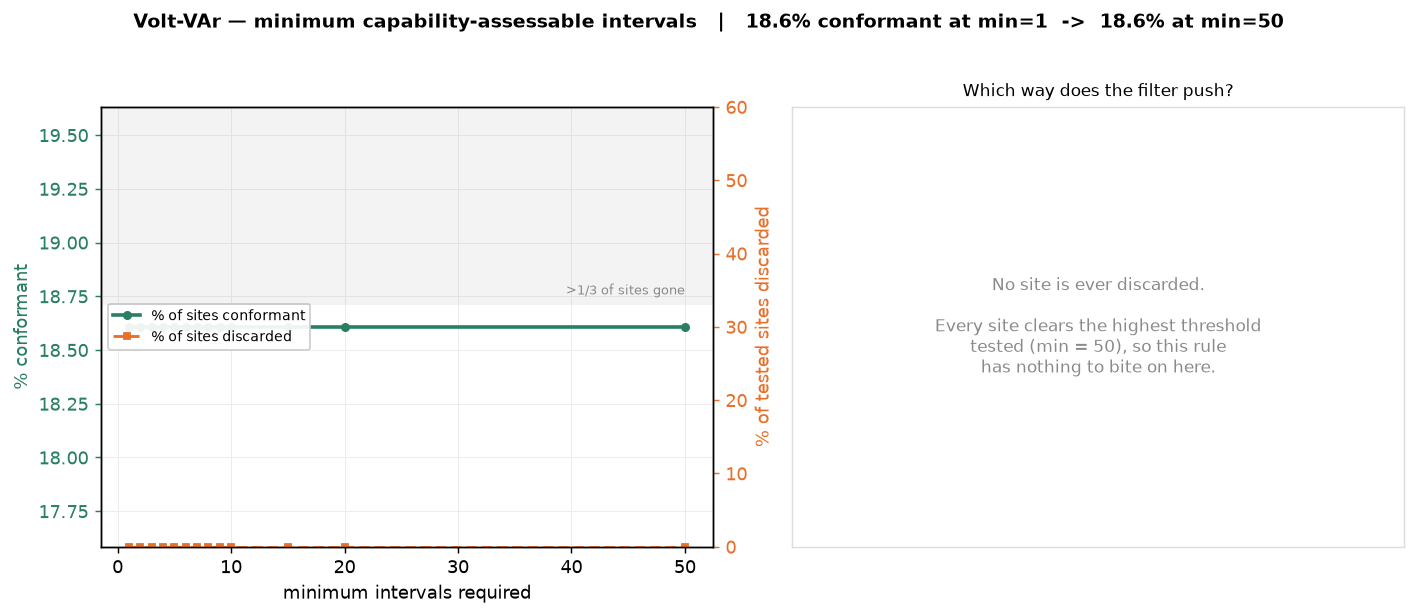

In [8]:
vv_min_sweep = sens.sweep_min_intervals(vvar_site_day, "voltvar", config)
display(vv_min_sweep.drop(columns="denominator"))
display(plots.plot_min_interval_sweep(
    vv_min_sweep, "Volt-VAr — minimum capability-assessable intervals"))

### Reading it

Compare the two curves before choosing anything. If Volt-Watt moves materially and
Volt-VAr does not, the minimum-interval rule is not a global analysis choice — it is
specific to how rarely this fleet sees 253 V, and it should be reported as such rather
than applied silently to both.

Whatever is chosen, `min_intervals` is already a parameter on
`voltwatt_verdict_measures`, `site_verdict_measures` and `denominator_comparison`, so
adopting a threshold is a one-line change in notebook 03 — not a rebuild.

In [9]:
summary = pd.DataFrame({
    "min_intervals": vw_min_sweep.min_intervals,
    "voltwatt_pct_conformant": vw_min_sweep.pct_conformant,
    "voltwatt_pct_sites_dropped": vw_min_sweep.pct_sites_dropped,
    "voltvar_pct_conformant": vv_min_sweep.pct_conformant,
    "voltvar_pct_sites_dropped": vv_min_sweep.pct_sites_dropped,
})
display(summary)

vw_span = vw_min_sweep.pct_conformant.max() - vw_min_sweep.pct_conformant.min()
vv_span = vv_min_sweep.pct_conformant.max() - vv_min_sweep.pct_conformant.min()
print(f"Headline moves across min=1..20:  Volt-Watt {vw_span:.1f} pp   "
      f"Volt-VAr {vv_span:.1f} pp")

vw_min_sweep.to_csv(C.ARTEFACT_DIR / "min_interval_sweep_voltwatt.csv", index=False)
vv_min_sweep.to_csv(C.ARTEFACT_DIR / "min_interval_sweep_voltvar.csv", index=False)

,min_intervals,voltwatt_pct_conformant,voltwatt_pct_sites_dropped,voltvar_pct_conformant,voltvar_pct_sites_dropped
0,1,80.977,0.000,18.608,0.0
1,2,78.689,14.834,18.608,0.0
2,3,77.996,19.895,18.608,0.0
3,4,77.397,23.560,18.608,0.0
4,5,76.887,26.003,18.608,0.0
5,6,77.037,29.319,18.608,0.0
6,7,77.261,32.461,18.608,0.0
7,8,76.965,35.602,18.608,0.0
8,9,76.860,36.649,18.608,0.0
9,10,76.667,37.173,18.608,0.0


Headline moves across min=1..20:  Volt-Watt 7.2 pp   Volt-VAr 0.0 pp


## What this establishes

The tornado tables name the choices each headline number is conditional on. Anything
near the top belongs in the limitations section, not a footnote.

On the current fleet the largest mover for Method A energy is the **capacity basis**
(`s_95` raises it ~67%), followed by the **reactive orientation** (~−28%). Both are
consequences of the same two gaps: no nameplate, and an unresolved sign convention.
Neither is a modelling preference, and both should be presented as data limitations.